In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False 
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
df = pd.read_parquet("../data/processed/transactions_sample.parquet")
articles = pd.read_parquet("../data/processed/articles.parquet")
customers = pd.read_parquet("../data/processed/customers.parquet")

In [3]:
df.shape, articles.shape, customers.shape

((569917, 5), (105542, 25), (1371980, 7))

### 구매 퍼널

In [4]:
user_purchase_counts = df.groupby("customer_id")["article_id"].count()
total_users = df["customer_id"].nunique()

funnel = pd.DataFrame({
    "단계": ["전체 유저", "1건 이상 구매", "3건 이상 구매", "5건 이상 구매"],
    "유저 수": [
        total_users,
        (user_purchase_counts >= 1).sum(),
        (user_purchase_counts >= 3).sum(),
        (user_purchase_counts >= 5).sum(),
    ],
})
funnel["비율(%)"] = (funnel["유저 수"] / total_users * 100).round(1)
funnel

,단계,유저 수,비율(%)
0,전체 유저,50000,100.0
1,1건 이상 구매,50000,100.0
2,3건 이상 구매,39266,78.5
3,5건 이상 구매,30862,61.7


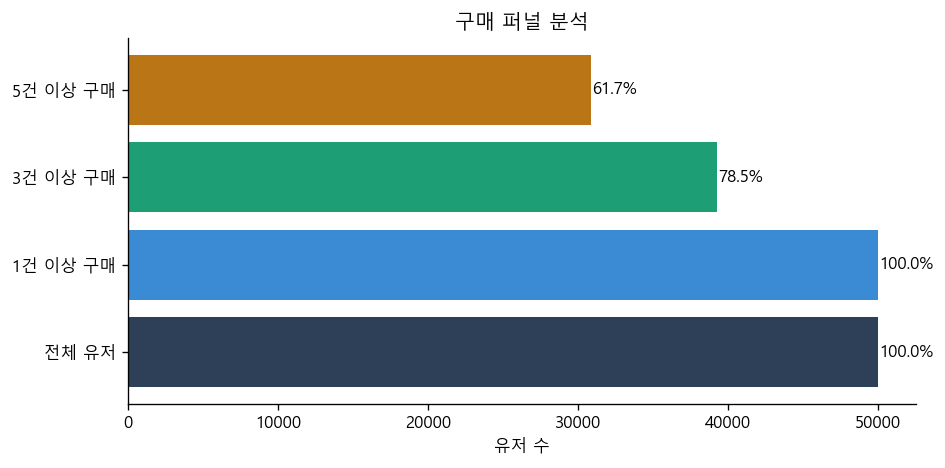

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#2E4057", "#3B8BD4", "#1D9E75", "#BA7517"]
bars = ax.barh(funnel["단계"], funnel["유저 수"], color=colors)

for i, (v, r) in enumerate(zip(funnel["유저 수"], funnel["비율(%)"])):
    ax.text(v + 100, i, f"{r}%", va="center", fontsize=10)

ax.set_xlabel("유저 수")
ax.set_title("구매 퍼널 분석")
plt.tight_layout()
plt.savefig("../data/processed/fig_funnel.png", bbox_inches="tight")
plt.show()

In [8]:
item_counts = df.groupby("article_id")["customer_id"].count().sort_values(ascending=False)
total_purchases = item_counts.sum()

top_1pct_n = max(1, int(len(item_counts) * 0.01))
top_1pct_share = item_counts.head(top_1pct_n).sum() / total_purchases * 100

top_5pct_n = max(1, int(len(item_counts) * 0.05))
top_5pct_share = item_counts.head(top_5pct_n).sum() / total_purchases * 100

pd.DataFrame({
    "구간": ["상위 1% 상품", "상위 5% 상품"],
    "상품 수": [top_1pct_n, top_5pct_n],
    "구매 점유율(%)": [round(top_1pct_share, 1), round(top_5pct_share, 1)],
})

,구간,상품 수,구매 점유율(%)
0,상위 1% 상품,328,14.7
1,상위 5% 상품,1640,38.7


### 인기 상품 집중도 (파레토)

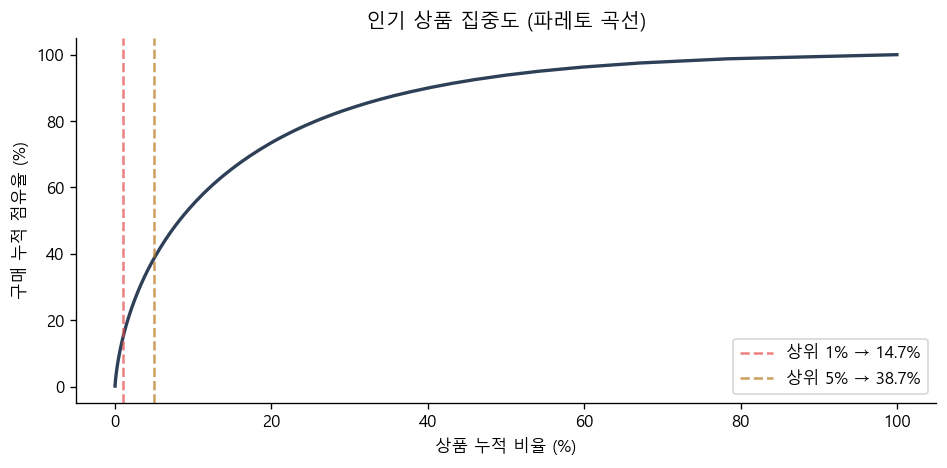

In [10]:
cumsum = item_counts.cumsum() / total_purchases * 100
item_pct = np.arange(1, len(item_counts) + 1) / len(item_counts) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(item_pct, cumsum.values, color="#2E4057", linewidth=2)
ax.axvline(x=1, color="#E24B4A", linestyle="--", alpha=0.7, label=f"상위 1% → {top_1pct_share:.1f}%")
ax.axvline(x=5, color="#BA7517", linestyle="--", alpha=0.7, label=f"상위 5% → {top_5pct_share:.1f}%")
ax.set_xlabel("상품 누적 비율 (%)")
ax.set_ylabel("구매 누적 점유율 (%)")
ax.set_title("인기 상품 집중도 (파레토 곡선)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_pareto.png", bbox_inches="tight")
plt.show()

### 유저 취향 다양성

In [11]:
user_category_diversity = (
    df.merge(articles[["article_id", "product_type_name"]], on="article_id", how="left")
    .groupby("customer_id")["product_type_name"]
    .nunique()
    .rename("unique_categories")
)

user_category_diversity.describe()

count    50000.000000
mean         5.091280
std          4.297897
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         43.000000
Name: unique_categories, dtype: float64

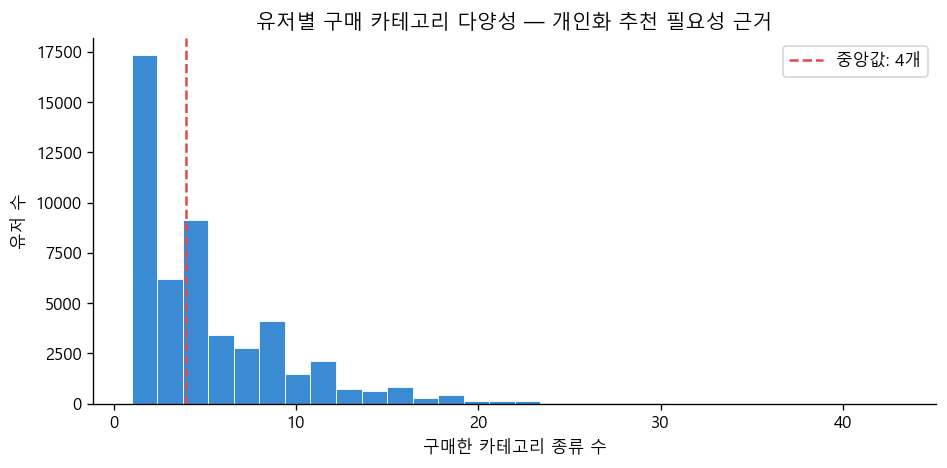

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_category_diversity, bins=30, color="#3B8BD4", edgecolor="white", linewidth=0.5)
ax.axvline(user_category_diversity.median(), color="#E24B4A", linestyle="--",
           label=f"중앙값: {user_category_diversity.median():.0f}개")
ax.set_xlabel("구매한 카테고리 종류 수")
ax.set_ylabel("유저 수")
ax.set_title("유저별 구매 카테고리 다양성 — 개인화 추천 필요성 근거")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_diversity.png", bbox_inches="tight")
plt.show()

### 월별 구매 트렌드

C:\Users\color\AppData\Local\Temp\ipykernel_13904\4067315738.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["article_id"]


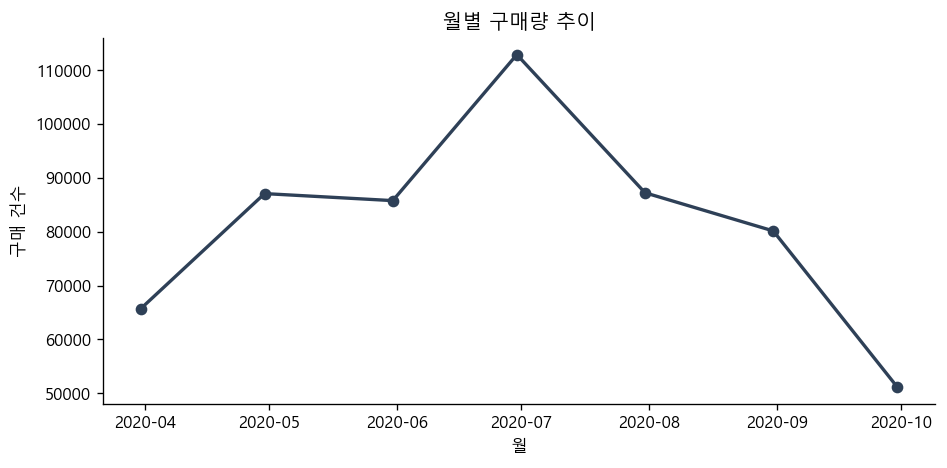

In [14]:
monthly = (
    df.set_index("t_dat")
    .resample("M")["article_id"]
    .count()
    .reset_index()
    .rename(columns={"t_dat": "month", "article_id": "purchase_count"})
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly["month"], monthly["purchase_count"], marker="o", color="#2E4057", linewidth=2)
ax.set_xlabel("월")
ax.set_ylabel("구매 건수")
ax.set_title("월별 구매량 추이")
plt.tight_layout()
plt.savefig("../data/processed/fig_monthly.png", bbox_inches="tight")
plt.show()

### 연령대별 구매 패턴

In [15]:
df_with_age = df.merge(
    customers[["customer_id", "age"]].dropna(),
    on="customer_id",
    how="left",
)

df_with_age["age_group"] = pd.cut(
    df_with_age["age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["~24", "25~34", "35~44", "45~54", "55~"],
)

age_stats = (
    df_with_age.groupby("age_group", observed=True)
    .agg(
        total_purchases=("article_id", "count"),
        unique_users=("customer_id", "nunique"),
        avg_price=("price", "mean"),
    )
    .reset_index()
)
age_stats["purchases_per_user"] = (
    age_stats["total_purchases"] / age_stats["unique_users"]
).round(2)
age_stats

,age_group,total_purchases,unique_users,avg_price,purchases_per_user
0,~24,141725,14597,0.025250,9.71
1,25~34,203795,15013,0.027384,13.57
2,35~44,67922,5282,0.027125,12.86
3,45~54,99933,8831,0.027683,11.32
4,55~,54412,5948,0.028841,9.15
